# Normalization
### It is a technique often applied as part of data preparation for machine learning. The goal of normalization is to change the values of numeric columns in the dataset to use a common scale, without distorting differences in the ranges of values or losing information.

## Types of it are
         - minmax scaling
         - Mean Normalization
         - Max Absolute 
         - Robust scaling

# 1. MinMax Scaling

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/placement.csv')

In [4]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


<Axes: xlabel='iq', ylabel='Density'>

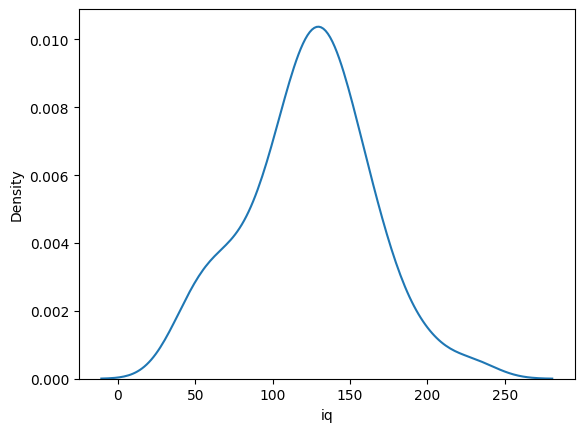

In [5]:
sns.kdeplot(df['iq'])

<Axes: xlabel='cgpa', ylabel='Density'>

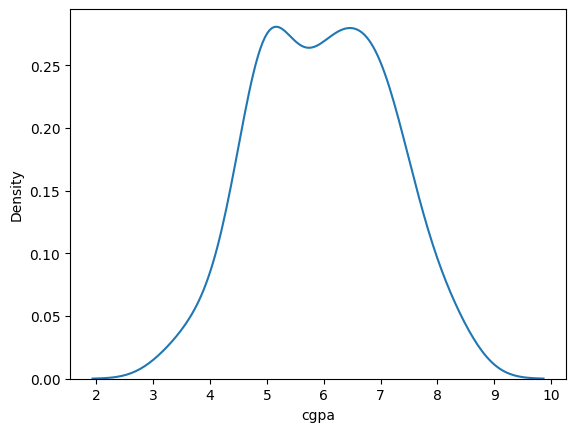

In [6]:
sns.kdeplot(df['cgpa'])

<Axes: xlabel='iq', ylabel='cgpa'>

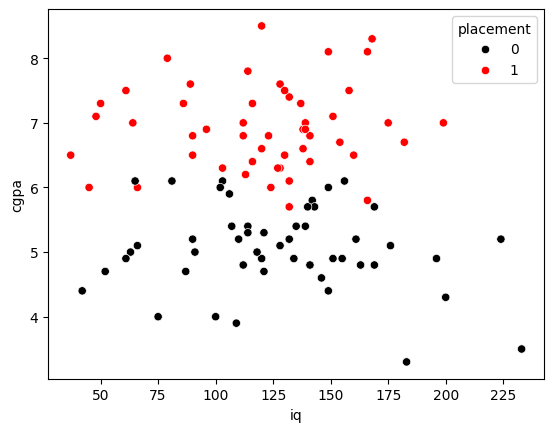

In [8]:
color_dict={0:'black',1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['iq'],y=df['cgpa'],hue=df['placement'],palette=color_dict)

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(df.drop('placement', axis=1),
                                               df['placement'],
                                               test_size=0.3,random_state=0)

In [11]:
x_train.shape, x_test.shape

((70, 3), (30, 3))

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()

scaler.fit(x_train)

x_train_scaled= scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [13]:
x_train_scaled= pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled= pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [14]:
x_train_scaled

,Unnamed: 0,cgpa,iq
0,0.612245,0.692308,0.507853
1,0.816327,0.307692,0.806283
2,0.918367,0.769231,0.230366
3,0.693878,0.134615,0.172775
4,0.520408,0.288462,0.518325
...,...,...,...
65,0.979592,0.211538,0.000000
66,0.683673,0.326923,0.397906
67,0.653061,0.711538,0.115183
68,0.479592,0.365385,0.623037


In [15]:
np.round(x_train_scaled.describe(),1)

,Unnamed: 0,cgpa,iq
count,70.0,70.0,70.0
mean,0.5,0.5,0.4
std,0.3,0.2,0.2
min,0.0,0.0,0.0
25%,0.3,0.3,0.3
50%,0.5,0.5,0.4
75%,0.7,0.7,0.6
max,1.0,1.0,1.0


Text(0.5, 1.0, 'After scaling')

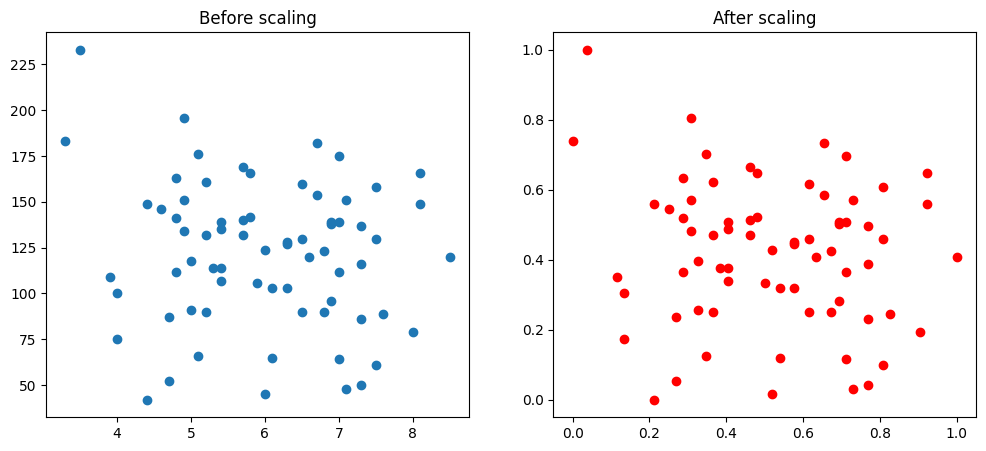

In [17]:
fig,(ax1, ax2)=plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['cgpa'],x_train['iq'])
ax1.set_title("Before scaling")
ax2.scatter(x_train_scaled['cgpa'],x_train_scaled['iq'],color='red')

ax2.set_title("After scaling")

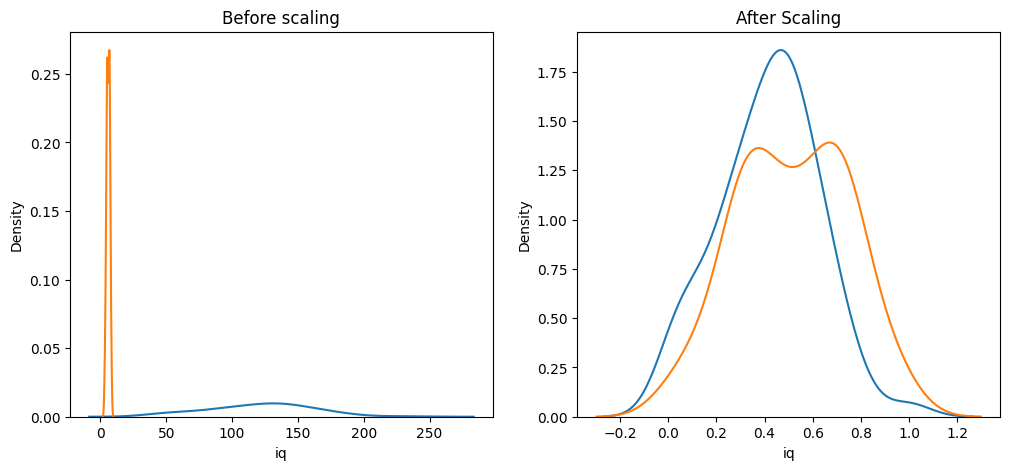

In [18]:
fig,(ax1, ax2)=plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before scaling')
sns.kdeplot(x_train['iq'],ax=ax1)
sns.kdeplot(x_train['cgpa'],ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled['iq'],ax=ax2)
sns.kdeplot(x_train_scaled['cgpa'],ax=ax2)
plt.show()

### For another type of scaling
     mean Normalization = Put the data into mean part means data revolves around origin,
                            ranges from (-1 to 1)
     MaxAbsolute = used in sparse data(having more zeros in data) 
     Robust scaling = It is robust to outlier, it handles those.